In [185]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math


In [186]:
HOLDS_HUE_RANGES = [
	# Orange
	[0, 45],
	# Yellow
	[45, 65],
	# Green
	[65, 140],
	# Blue
	[210, 250],
	# Purple
	[250, 270],
	# Pink
	[290, 320]
]

In [187]:
def resize(img, desired_width = 600):
	(h, w) = img.shape[:2]
	aspect_ratio = h / w
	new_height = int(desired_width * aspect_ratio)
	return cv2.resize(img, (desired_width, new_height))

def quantize(img, k = 8):
	pixels = img.reshape((-1, 3))
	pixels = np.float32(pixels)

	criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

	_, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

	centers = np.uint8(centers)

	quantized_image = centers[labels.flatten()]
	quantized_image = quantized_image.reshape(img.shape)

	return quantized_image

def hsl_to_hsv(hue, saturation, luminance):
	return np.array([hue / 2 - 1, (saturation / 100) * 255, (luminance / 100) * 255])

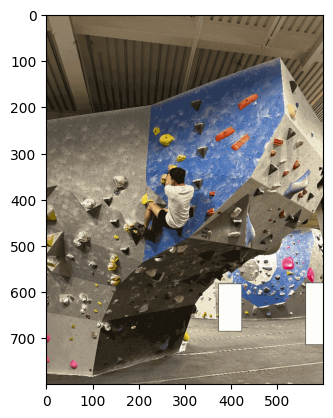

In [188]:
img = cv2.imread("./images/IMG_4705.png")
img = resize(img)
img = quantize(img, k = 100)

safe_for_human_eyes_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(safe_for_human_eyes_img)
plt.show()

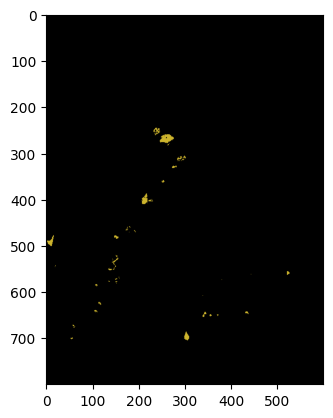

In [189]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# low and high for yellow range
[low, high] = HOLDS_HUE_RANGES[1]

mask = cv2.inRange(hsv, hsl_to_hsv(*[low, 50, 50]), hsl_to_hsv(*[high, 100, 100]))
result = cv2.bitwise_and(img, img, mask=mask)
result = quantize(result, k = 2)

safe_for_human_eyes_result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.imshow(safe_for_human_eyes_result)
plt.show()

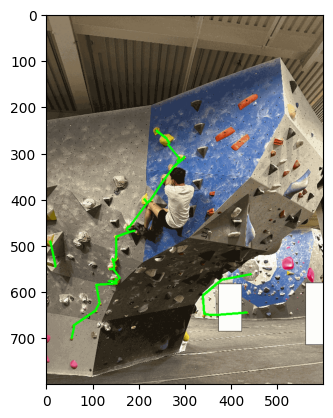

In [190]:
num_of_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    mask)

output = img.copy()

distances = []
closest_points = []

# Skip first label since it is the background
for i in range(1, num_of_labels - 1):
    x2: int | None
    y2: int | None
    min_distance = None

    for j in range(i + 1, num_of_labels):
        distance = math.dist(centroids[i], centroids[j])
        if min_distance is None or distance < min_distance:
            min_distance = distance
            x2 = int(centroids[j][0])
            y2 = int(centroids[j][1])

    distances.append(min_distance)
    closest_points.append((x2, y2))

sorted_distances = sorted(distances)
median = sorted_distances[math.floor(len(sorted_distances) / 2)]

for i in range(1, num_of_labels - 1):
    # Figure out a better way to filter outliers of extreme distance (e.g. holds which are too far from the "main" path and should not be included when drawing)
    if distances[i - 1] >= median * 5:
        continue
    
    hold_center = [int(coord) for coord in centroids[i]]
    cv2.line(output, hold_center, closest_points[i - 1], (0, 255, 0), 3)


safe_for_human_eyes_img = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
plt.imshow(safe_for_human_eyes_img)
plt.show()

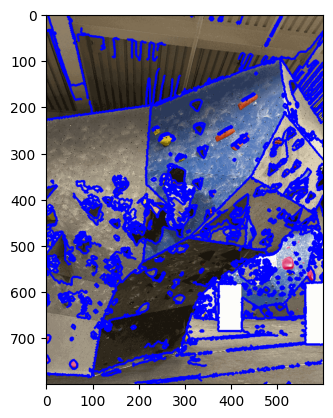

In [206]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

mask = cv2.inRange(hsv, hsl_to_hsv(
    *[0, 0, 0]), hsl_to_hsv(*[45, 50, 100]))
result = cv2.bitwise_and(img, img, mask=mask)
result = cv2.GaussianBlur(result, (5, 5), 1.4)
result = quantize(result, k=8)
result = cv2.Canny(result, 100, 200)
contours, hierarchy = cv2.findContours(result, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
output = img.copy()
cv2.drawContours(output, contours, -1, (255,0,0), 3)

safe_for_human_eyes_result = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
plt.imshow(safe_for_human_eyes_result)
plt.show()